<a href="https://colab.research.google.com/github/agamiit/Explonatroy_Data_Analaysis--EDA-/blob/main/Blinkit_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/blinkit_data.csv")

In [41]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [106]:
#Check the No.of Rows and Columns>>
print("Size of Data:\n",df.shape)

Size of Data:
 (8523, 12)


In [110]:
#Field Info
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [66]:
#Check the DataType of each columns??
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                8523 non-null   float64
 10  Sales                      8523 non-null   int64  
 11  Rating                     8523 non-null   float64
dtypes: float64(3), int64(2), object(7)
memory usage: 799.2+ KB


In [111]:
#Check the Descriptive Statistics of this Dataset??
df.describe().T.round(2).replace(".00"," ")

,count,mean,std,min,25%,50%,75%,max
Outlet Establishment Year,8523.0,2010.83,8.37,1998.00,2000.00,2012.00,2017.00,2022.00
Item Visibility,8523.0,0.07,0.05,0.00,0.03,0.05,0.09,0.33
Item Weight,8523.0,12.86,4.23,4.56,9.31,12.86,16.00,21.35
Sales,8523.0,140.50,62.28,31.00,93.00,143.00,185.00,266.00
Rating,8523.0,3.97,0.61,1.00,4.00,4.00,4.20,5.00


In [68]:
df.isnull().sum()

,0
Item Fat Content,0
Item Identifier,0
Item Type,0
Outlet Establishment Year,0
Outlet Identifier,0
Outlet Location Type,0
Outlet Size,0
Outlet Type,0
Item Visibility,0
Item Weight,0


In [116]:
#Data Cleaning in "Item Fat Content"
IFC = df["Item Fat Content"].value_counts()

df["Item Fat Content"] = df["Item Fat Content"].replace({
    "low fat" : "Low Fat",
    "LF" : "Low Fat",
    "reg" : "Regular"

})

display(IFC)


,count
Item Fat Content,
Low Fat,5517
Regular,3006


In [119]:
df["Item Type"].value_counts()

,count
Item Type,
Fruits and Vegetables,1232
Snack Foods,1200
Household,910
Frozen Foods,856
Dairy,682
Canned,649
Baking Goods,648
Health and Hygiene,520
Soft Drinks,445


# **BUSINESS REQUIREMENTS**

In [69]:
df["Item Weight"] = df["Item Weight"].fillna(df["Item Weight"].mean())

In [146]:
#KPI's Total Sales : Overall Revenue generated from item sold??

TS = df["Sales"].sum()
TS

print(f"Total Sales : ${TS:,.0f}")

Total Sales : $1,197,479
Sales as per Category:
Item Type
Fruits and Vegetables    177520
Snack Foods              174834
Household                135523
Frozen Foods             118148
Dairy                    100940
Canned                    90393
Baking Goods              81593
Health and Hygiene        67771
Meat                      59231
Soft Drinks               58299
Breads                    35249
Hard Drinks               29225
Others                    22368
Starchy Foods             21798
Breakfast                 15541
Seafood                    9046
Name: Sales, dtype: int64


In [71]:
df["Sales"] = df["Sales"].round(2).astype(int)

In [172]:
#Average Sales : Avg Revenue Per Sales??

AS = df["Sales"].mean()
AS

AS1 = df.groupby("Item Type")["Sales"].mean().sort_values(ascending=False)
AS1.astype(int).reset_index()

print(f"Total Sales:${AS:,.2f}")
print(f"Sales as per Category:\n{AS1.round(2)}")


Total Sales:$140.50
Sales as per Category:
Item Type
Household                148.93
Dairy                    148.01
Starchy Foods            147.28
Snack Foods              145.70
Fruits and Vegetables    144.09
Seafood                  141.34
Breakfast                141.28
Breads                   140.43
Meat                     139.37
Canned                   139.28
Frozen Foods             138.02
Hard Drinks              136.57
Others                   132.36
Soft Drinks              131.01
Health and Hygiene       130.33
Baking Goods             125.92
Name: Sales, dtype: float64


In [183]:
#No. of items : Total Count of different items Sold??
TC = df["Sales"].count()
TC1 = df.groupby("Item Type")["Sales"].count().sort_values(ascending=False).reset_index()

print(f"Total Count:{TC:,.1f}")
print(f"Count as per Category:\n{TC1}")

Total Count:8,523.0
Count as per Category:
                Item Type  Sales
0   Fruits and Vegetables   1232
1             Snack Foods   1200
2               Household    910
3            Frozen Foods    856
4                   Dairy    682
5                  Canned    649
6            Baking Goods    648
7      Health and Hygiene    520
8             Soft Drinks    445
9                    Meat    425
10                 Breads    251
11            Hard Drinks    214
12                 Others    169
13          Starchy Foods    148
14              Breakfast    110
15                Seafood     64


In [191]:
#Avg Rating : Avg customer rating for item sold??
AC = df["Sales"].mean()
AC1 = df.groupby("Item Type")["Rating"].mean().sort_values(ascending=False).reset_index().round(2)

print(f"Avg Rating:${AC:,.2f}")
print(f"Rating as per Category:\n{AC1.round(1)}")

Avg Rating:$140.50
Rating as per Category:
                Item Type  Rating
0                    Meat     4.0
1               Household     4.0
2                  Canned     4.0
3      Health and Hygiene     4.0
4            Baking Goods     4.0
5            Frozen Foods     4.0
6                   Dairy     4.0
7                 Seafood     4.0
8   Fruits and Vegetables     4.0
9                  Others     4.0
10            Snack Foods     4.0
11              Breakfast     3.9
12            Soft Drinks     3.9
13          Starchy Foods     3.9
14            Hard Drinks     3.9
15                 Breads     3.9


# **CHART REQUIREMENTS**

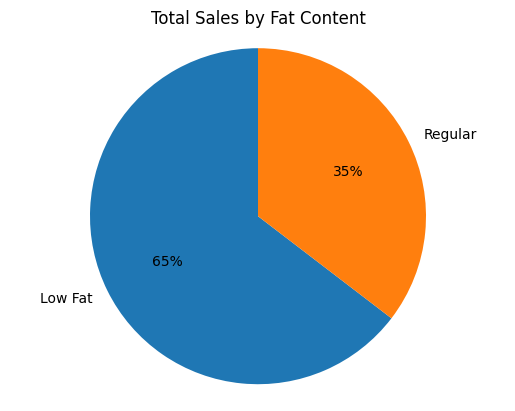

In [206]:
#Total Salesby Fat Content??
TSFC = df.groupby("Item Fat Content")["Sales"].sum().sort_values(ascending=False)

#Create a pie chart??
plt.pie(TSFC, labels=TSFC.index,
        autopct="%.0f%%",
        startangle=90)

plt.title("Total Sales by Fat Content")
plt.axis("equal")
plt.show()

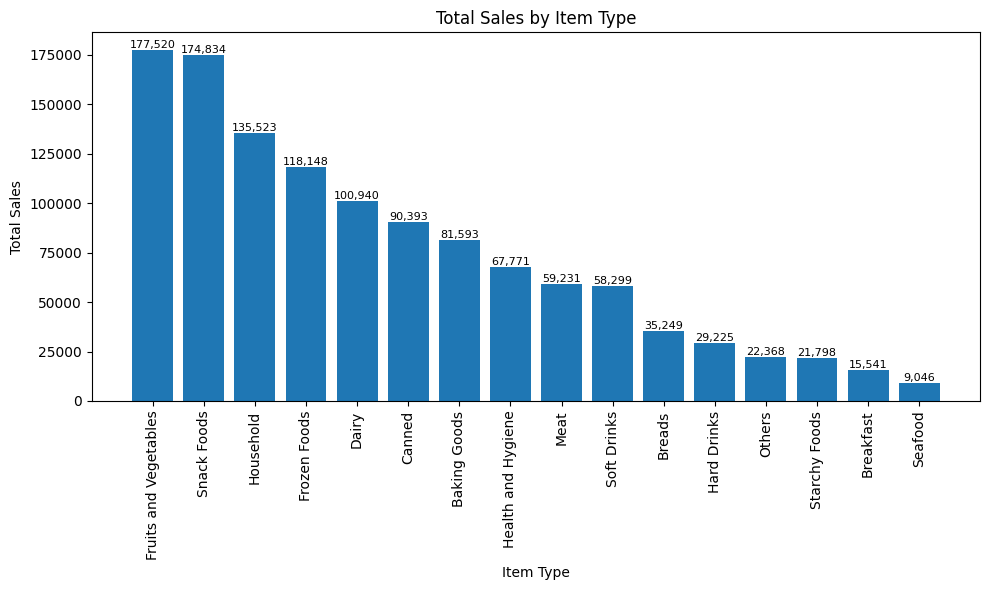

Sales as per Category:
Item Type
Fruits and Vegetables    177520
Snack Foods              174834
Household                135523
Frozen Foods             118148
Dairy                    100940
Canned                    90393
Baking Goods              81593
Health and Hygiene        67771
Meat                      59231
Soft Drinks               58299
Breads                    35249
Hard Drinks               29225
Others                    22368
Starchy Foods             21798
Breakfast                 15541
Seafood                    9046
Name: Sales, dtype: int64


In [241]:
#Total Sales by item type??
TS1 = df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False)
TS1.astype(int).reset_index()

plt.figure(figsize=(10, 6))

bars = plt.bar(TS1.index, TS1.values)
plt.xlabel("Item Type")
plt.ylabel("Total Sales")
plt.title("Total Sales by Item Type")
plt.xticks(rotation=90)

#Data Labels>>
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height(),
             f"{bar.get_height():,.0f}",
             ha="center",
             va="bottom",
             fontsize =8)

plt.tight_layout()
plt.show()

print(f"Sales as per Category:\n{TS1}")

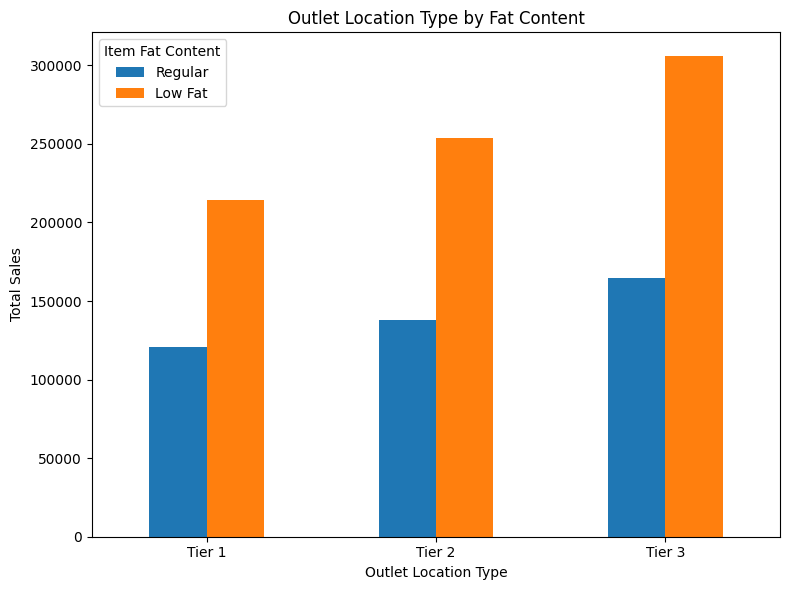

In [258]:
#Fat Content by Outlet and Total Sales??
grouped = df.groupby(["Outlet Location Type","Item Fat Content"])["Sales"].sum().unstack()
grouped = grouped[["Regular","Low Fat"]]

ax = grouped.plot(kind="bar", figsize=(8,6), title= "Outlet Location Type by Fat Content")
plt.xlabel("Outlet Location Type")
plt.ylabel("Total Sales")
plt.legend(title="Item Fat Content")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


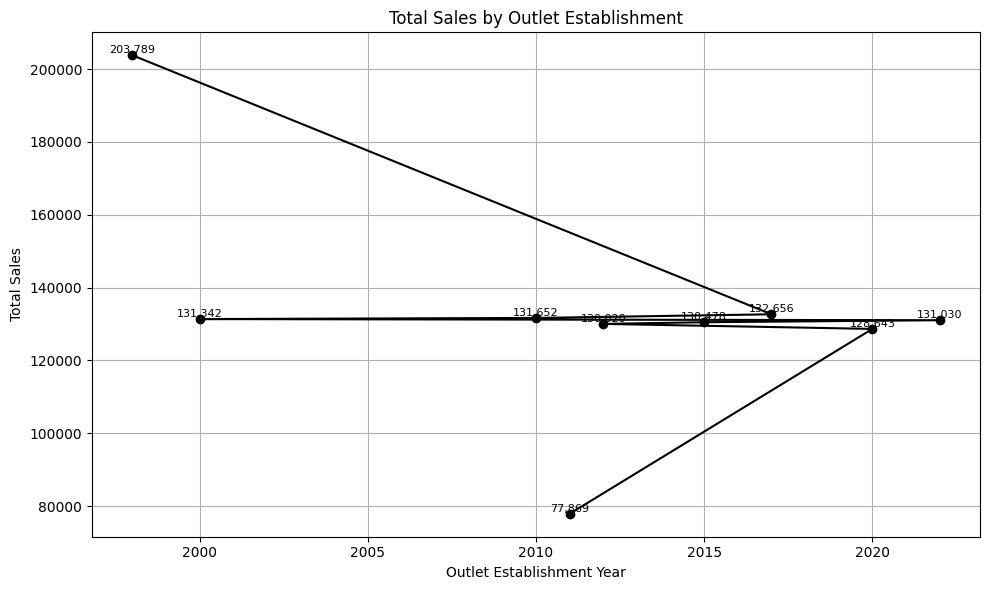

In [277]:
  #Total Sales by outlet Establishment??
TSO = df.groupby("Outlet Establishment Year")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.plot(TSO.index,TSO.values , marker='o', linestyle='-', color='black')
plt.xlabel("Outlet Establishment Year")
plt.ylabel("Total Sales")

for x, y in zip(TSO.index,TSO.values):
    plt.text(x,y,f"{y:,.0f}", ha="center", va="bottom", fontsize=8)

plt.title("Total Sales by Outlet Establishment")
plt.grid(True)
plt.tight_layout()
plt.show()

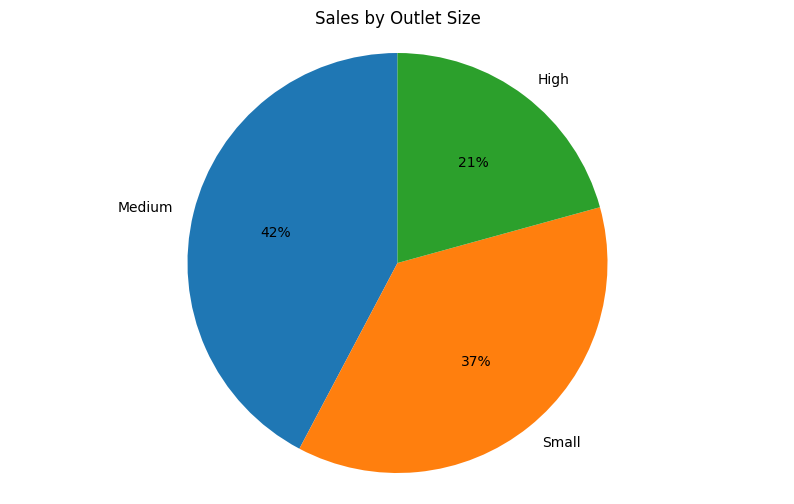

In [289]:
#Sales by outlet size??
OZ = df.groupby("Outlet Size")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.pie(OZ,labels=OZ.index,
        autopct="%.0f%%",
        startangle=90)

plt.title("Sales by Outlet Size")
plt.axis("equal")
plt.show()